# 🚀 Tái Lập LiDAR Bảng 2 Trên Google Colab (GPU A100 / L4)

Notebook này được tối ưu hóa toàn diện cho **Google Colab Pro+ (GPU NVIDIA A100 hoặc L4)**:
- **Tập trung 100% tái lập Bảng 2**: Gồm Phase 1 (Lookahead DPM-5, 50 hạt), Phase 2 (LiDAR DDIM-50, 4 hạt, scale=15.0) và Native GenEval Benchmark.
- **Tốc độ tối đa**: Kích hoạt Full-Batch VAE Decoding nguyên bản khớp chuẩn bài báo gốc ICML 2026 Spotlight (KAIST).
- **Lưu trữ liên tục (Real-time Drive Persistence)**: Toàn bộ ảnh mẫu, latents và điểm số được lưu tức thì ra Google Drive sau mỗi prompt qua Symbolic Link.
- **Tiếp tục thông minh (`--resume`)**: Tự động tiếp tục từ prompt chưa hoàn thành nếu mạng bị gián đoạn.
- **Thời gian hoàn thành**: ~1.5 đến 2.0 giờ cho trọn vẹn 553 prompt.

## 1. Kiểm Tra Phần Cứng GPU & VRAM
Đảm bảo bạn đã chọn Runtime: **Runtime -> Change runtime type -> A100 (hoặc L4) GPU** và bật **High-RAM**.

In [ ]:
import torch, sys, os
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA khả dụng:", torch.cuda.is_available())

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)
    print(f"🎮 GPU: {gpu_name}")
    print(f"💾 VRAM: {vram_gb} GB")
    if vram_gb >= 22.0:
        print("✅ Tuyệt vời! GPU có đủ VRAM để kích hoạt Full-Batch VAE Decoding tốc độ cao.")
    else:
        print("⚠️ Chú ý: GPU dưới 22GB VRAM, code sẽ tự động dùng chunking để bảo vệ bộ nhớ.")
else:
    raise RuntimeError("❌ Không phát hiện GPU CUDA! Vui lòng vào Runtime -> Change runtime type -> Chọn GPU.")

!nvidia-smi

Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA khả dụng: True
🎮 GPU: NVIDIA A100-SXM4-40GB
💾 VRAM: 42.41 GB
✅ Tuyệt vời! GPU có đủ VRAM để kích hoạt Full-Batch VAE Decoding tốc độ cao.
Sun Sep 13 16:32:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             47W /  400W |       6

## 2. Gắn Kết Google Drive & Thiết Lập Lưu Trữ Tức Thì (Real-time Persistence)
Toàn bộ kết quả sẽ được ghi trực tiếp vào `My Drive/RS-LiDAR/` thông qua symlink. Sau mỗi prompt hoàn thành, file `.png`, `latent.pt` và `results.json` được lưu vĩnh viễn trên Drive.

In [ ]:
import os, shutil, subprocess
from google.colab import drive

# 1. Gắn kết Google Drive an toàn
drive.mount('/content/drive')

base_drive = "/content/drive/My Drive" if os.path.exists("/content/drive/My Drive") else "/content/drive/MyDrive"
assert os.path.exists(base_drive), f"❌ Không tìm thấy thư mục Google Drive tại {base_drive}! Vui lòng gắn kết lại Drive."

DRIVE_DIR = f"{base_drive}/RS-LiDAR"
os.makedirs(f"{DRIVE_DIR}/Lookahead_samples", exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/Target_samples", exist_ok=True)

# 2. Clone hoặc kéo cập nhật repo RS-LiDAR tự động
REPO_DIR = "/content/RS-LiDAR"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", "https://github.com/leekwanreal/RS-LiDAR.git", REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull", "origin", "main"], check=True)

WORKDIR = REPO_DIR if os.path.exists(f"{REPO_DIR}/lookahead_sampling.py") else f"{REPO_DIR}/Diffusion-LiDAR-Sampling"
%cd {WORKDIR}

# 3. Tạo Symbolic Links an toàn (Tuyệt đối không xóa dữ liệu cũ, tự động migrate nếu có file cục bộ)
for folder_name in ["Lookahead_samples", "Target_samples"]:
    link_path = os.path.join(WORKDIR, folder_name)
    drive_target = os.path.join(DRIVE_DIR, folder_name)
    os.makedirs(drive_target, exist_ok=True)

    if os.path.islink(link_path):
        if not os.path.exists(link_path):
            os.remove(link_path)
            os.symlink(drive_target, link_path)
    elif os.path.exists(link_path):
        print(f"📦 Phát hiện thư mục cục bộ {folder_name}, đang đồng bộ an toàn sang Google Drive...")
        for item in os.listdir(link_path):
            src_item = os.path.join(link_path, item)
            dst_item = os.path.join(drive_target, item)
            if not os.path.exists(dst_item):
                if os.path.isdir(src_item):
                    shutil.copytree(src_item, dst_item)
                else:
                    shutil.copy2(src_item, dst_item)
        shutil.rmtree(link_path)
        os.symlink(drive_target, link_path)
    else:
        os.symlink(drive_target, link_path)

print("✅ Hệ thống Symlink đã sẵn sàng 100%! Toàn bộ dữ liệu được bảo lưu vĩnh viễn trên Drive:")
print("  📁", DRIVE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/RS-LiDAR
✅ Hệ thống Symlink đã sẵn sàng 100%! Toàn bộ dữ liệu được bảo lưu vĩnh viễn trên Drive:
  📁 /content/drive/My Drive/RS-LiDAR


## 3. Cài Đặt Môi Trường Chuẩn Xác (100% Trơn Tru & Không Xung Đột)
Cài đặt bộ thư viện đồng bộ, tắt backend TensorFlow để chống xung đột Protobuf, và tải vocab HPSv2.

In [ ]:
import os, urllib.request

# 1. Tắt backend TensorFlow để loại bỏ xung đột Protobuf runtime_version
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

# 2. Nâng cấp protobuf và cài đặt các thư viện tương thích PyTorch 2.x
!pip install -q --upgrade protobuf
!pip install -q transformers==4.38.2 diffusers==0.31.0 accelerate==1.2.1 safetensors huggingface-hub einops ftfy timm peft
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q git+https://github.com/THUDM/ImageReward.git
!pip install -q hpsv2 matplotlib tqdm scipy seaborn pandas tabulate

# 3. Đảm bảo file từ điển OpenCLIP cho HPSv2
import hpsv2
hpsv2_vocab = os.path.join(os.path.dirname(hpsv2.__file__), "src", "open_clip", "bpe_simple_vocab_16e6.txt.gz")
os.makedirs(os.path.dirname(hpsv2_vocab), exist_ok=True)
if not os.path.exists(hpsv2_vocab):
    print("📥 Đang tải file BPE vocab cho HPSv2...")
    urllib.request.urlretrieve("https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz", hpsv2_vocab)

print("✅ Cài đặt môi trường hoàn tất 100%!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hpsv2 1.2.0 requires protobuf<4, but you have protobuf 7.36.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1 which is incompatible.
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
proto-plus 1.28.2 requires protobuf<8.0.0,>=4.25.8, but yo

## 4. Cấu Hình Siêu Tham Số Chuẩn Bảng 2 & Kiểm Tra Tiến Độ Sẵn Có
Cấu hình siêu tham số chuẩn từ phụ lục B.1 của bài báo ($s=12.5, \lambda=5000, t_{end}=200, n=50$).

In [ ]:
import glob, os, json

# ==============================================================================
# 🎯 1. CHỌN MÔ HÌNH VÀ TỰ ĐỘNG THIẾT LẬP SIÊU THAM SỐ CHUẨN BẢNG 2
# ==============================================================================
MODEL_CHOICE = "SDXL-DPM-8"
# Các tùy chọn khả dụng: "SD1.5", "SDXL-DPM-8", "SDXL-LCM-4", "SDXL-DMD-1"

if MODEL_CHOICE == "SD1.5":
    MODEL_NAME_P1 = "runwayml/stable-diffusion-v1-5"
    MODEL_NAME_P2 = "runwayml/stable-diffusion-v1-5"
    MODEL_TAG = "SD15"
    SCALE = 12.5
    STEPS_P1 = 5
    NUM_PARTICLES_P1 = 50

elif MODEL_CHOICE == "SDXL-DPM-8":
    MODEL_NAME_P1 = "stabilityai/stable-diffusion-xl-base-1.0"
    MODEL_NAME_P2 = "stabilityai/stable-diffusion-xl-base-1.0"
    MODEL_TAG = "SDXL_DPM8"
    SCALE = 8.0
    STEPS_P1 = 8
    NUM_PARTICLES_P1 = 50

elif MODEL_CHOICE == "SDXL-LCM-4":
    MODEL_NAME_P1 = "latent-consistency/lcm-lora-sdxl"
    MODEL_NAME_P2 = "stabilityai/stable-diffusion-xl-base-1.0"
    MODEL_TAG = "SDXL_LCM4"
    SCALE = 8.0
    STEPS_P1 = 4
    NUM_PARTICLES_P1 = 100 # Chuẩn Bảng 2 cho LCM-4 là n=100

elif MODEL_CHOICE == "SDXL-DMD-1":
    MODEL_NAME_P1 = "dmd2_sdxl_1step_unet_fp16.bin"
    MODEL_NAME_P2 = "stabilityai/stable-diffusion-xl-base-1.0"
    MODEL_TAG = "SDXL_DMD1"
    SCALE = 8.0
    STEPS_P1 = 1
    NUM_PARTICLES_P1 = 100 # Chuẩn Bảng 2 cho DMD-1 là n=100

else:
    raise ValueError("Lựa chọn mô hình không hợp lệ!")

# Các tham số dùng chung
SEED_P1 = 100
SEED_P2 = 100
MAX_PROMPT = 553
LAMBDA = 5000.0
RESAMPLE_T_END = 200
NUM_PARTICLES_P2 = 4
STEPS_P2 = 100         # DDPM 100 bước chuẩn Bảng 2
ETA_P2 = 1.0           # 1.0 = DDPM, 0.0 = DDIM

# ==============================================================================
# 🧪 2. CẤU HÌNH RANDOMIZED SMOOTHING (RS-LIDAR PHASE 1)
# ==============================================================================
USE_SMOOTHING = True
SIGMA = 1.0
NUM_MC_SAMPLES = 4

REUSE_LATENTS_FROM = f"Lookahead_{MODEL_TAG}_DPM{STEPS_P1}_n{NUM_PARTICLES_P1}_seed{SEED_P1}"

OVERWRITE_PHASE1 = False
OVERWRITE_PHASE2 = False

# ==============================================================================
# 🏷️ 3. ĐẶT TÊN THƯ MỤC CHUẨN KHOA HỌC DỰA TRÊN MODEL_TAG
# ==============================================================================
prior_candidates = [
    f"{WORKDIR}/Lookahead_samples/{REUSE_LATENTS_FROM}",
    f"{WORKDIR}/Lookahead_samples/100_{NUM_PARTICLES_P1}_{STEPS_P1}"
]
prior_dir = next((p for p in prior_candidates if os.path.exists(p)), prior_candidates[0])

SOLVER_TAG = f"DDPM{STEPS_P2}" if ETA_P2 == 1.0 else (f"DDIM{STEPS_P2}" if ETA_P2 == 0.0 else f"DDIM{STEPS_P2}_eta{ETA_P2}")

if USE_SMOOTHING:
    LOOKAHEAD_TAG = f"RSLookahead_{MODEL_TAG}_Step{STEPS_P1}_n{NUM_PARTICLES_P1}_sig{SIGMA}_M{NUM_MC_SAMPLES}_seed{SEED_P1}"
    RUN_NAME = f"RSLiDAR_{MODEL_TAG}_Step{STEPS_P1}_n{NUM_PARTICLES_P1}_sig{SIGMA}_M{NUM_MC_SAMPLES}_{SOLVER_TAG}_s{SCALE}_lmbda{int(LAMBDA)}_seed{SEED_P2}_A100"
else:
    if os.path.exists(prior_dir) and len(glob.glob(f"{prior_dir}/[0-9]*/results.json")) > 0:
        LOOKAHEAD_TAG = os.path.basename(prior_dir)
    else:
        LOOKAHEAD_TAG = f"Lookahead_{MODEL_TAG}_Step{STEPS_P1}_n{NUM_PARTICLES_P1}_seed{SEED_P1}"
    RUN_NAME = f"LiDAR_{MODEL_TAG}_Step{STEPS_P1}_n{NUM_PARTICLES_P1}_{SOLVER_TAG}_s{SCALE}_lmbda{int(LAMBDA)}_seed{SEED_P2}_A100"

lookahead_dir = f"{WORKDIR}/Lookahead_samples/{LOOKAHEAD_TAG}"
target_dir = f"{WORKDIR}/Target_samples/{RUN_NAME}"

existing_prior = len(glob.glob(f"{prior_dir}/[0-9]*/samples/latent.pt"))
existing_look = len(glob.glob(f"{lookahead_dir}/[0-9]*/results.json"))
existing_targ = len(glob.glob(f"{target_dir}/[0-9]*/results.json"))

print(f"📊 TIẾN ĐỘ THỰC NGHIỆM TRÊN GOOGLE DRIVE (MÔ HÌNH {MODEL_TAG}):")
print(f"  📁 Thư mục Phase 1 (Lookahead): {LOOKAHEAD_TAG}")
print(f"  📁 Thư mục Phase 2 (Target):    {RUN_NAME}")
print(f"  ----------------------------------------------------------------------")
print(f"  • Latents đã có sẵn: {existing_prior}/{MAX_PROMPT} prompts")
print(f"  • Phase 1 Lookahead hoàn thành: {existing_look}/{MAX_PROMPT} prompts")
print(f"  • Phase 2 Target Sampling hoàn thành: {existing_targ}/{MAX_PROMPT} prompts")
print(f"  ----------------------------------------------------------------------")

if existing_look >= MAX_PROMPT:
    print("  ✅ Phase 1 đã có đầy đủ kết quả! TỰ ĐỘNG SKIP Phase 1.")
elif existing_prior > 0:
    print("  ⚡ Đã tìm thấy latents có sẵn! Phase 1 sẽ tận dụng lại.")

📊 TIẾN ĐỘ THỰC NGHIỆM TRÊN GOOGLE DRIVE (MÔ HÌNH SDXL_DPM8):
  📁 Thư mục Phase 1 (Lookahead): RSLookahead_SDXL_DPM8_Step8_n50_sig1.0_M4_seed100
  📁 Thư mục Phase 2 (Target):    RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100
  ----------------------------------------------------------------------
  • Latents đã có sẵn: 0/553 prompts
  • Phase 1 Lookahead hoàn thành: 270/553 prompts
  • Phase 2 Target Sampling hoàn thành: 0/553 prompts
  ----------------------------------------------------------------------


## 5. Phase 1: Lấy Mẫu Lookahead & Đánh Giá Reward (Lookahead Sampling)
Chạy bộ giải DPM-5 ($S=5$ bước) sinh $n=50$ hạt cho mỗi prompt.

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
%cd {WORKDIR}

if existing_look >= MAX_PROMPT and not OVERWRITE_PHASE1:
    print("=" * 70)
    print(f"✅ TỰ ĐỘNG SKIP PHASE 1: Thư mục '{LOOKAHEAD_TAG}' đã có đủ {existing_look}/{MAX_PROMPT} prompts!")
    print("=" * 70)
else:
    cmd = [
        "python", "lookahead_sampling.py",
        f"--seed={SEED_P1}",
        f"--num_particles={NUM_PARTICLES_P1}",
        f"--num_inference_steps={STEPS_P1}",
        f"--model_name={MODEL_NAME_P1}",       # 👈 Sử dụng mô hình Lookahead (VD: DMD, LCM)
        "--guidance_reward_fn=ImageReward",
        "--metrics_to_compute=ImageReward#Clip-Score",
        "--prompt_path=prompt_files/geneval_metadata.jsonl",
        f"--max_prompt={MAX_PROMPT}",
        f"--run_name={LOOKAHEAD_TAG}",
        "--resume"
    ]

    if os.path.exists(prior_dir) and existing_prior > 0:
        cmd.append(f"--reuse_latents_from={os.path.basename(prior_dir)}")

    if USE_SMOOTHING:
        cmd.extend([
            "--use_smoothing",
            f"--sigma={SIGMA}",
            f"--num_mc_samples={NUM_MC_SAMPLES}"
        ])

    if OVERWRITE_PHASE1:
        cmd.append("--overwrite")

    cmd_str = " \\\n    ".join(cmd)
    phase_desc = "RS-LiDAR Lookahead" if USE_SMOOTHING else "Vanilla Lookahead"
    print(f"🚀 Đang khởi chạy Phase 1 ({phase_desc}):")
    print(cmd_str)
    print("-" * 70)
    !{" ".join(cmd)}

/content/RS-LiDAR
🚀 Đang khởi chạy Phase 1 (RS-LiDAR Lookahead):
python \
    lookahead_sampling.py \
    --seed=100 \
    --num_particles=50 \
    --num_inference_steps=8 \
    --model_name=stabilityai/stable-diffusion-xl-base-1.0 \
    --guidance_reward_fn=ImageReward \
    --metrics_to_compute=ImageReward#Clip-Score \
    --prompt_path=prompt_files/geneval_metadata.jsonl \
    --max_prompt=553 \
    --run_name=RSLookahead_SDXL_DPM8_Step8_n50_sig1.0_M4_seed100 \
    --resume \
    --use_smoothing \
    --sigma=1.0 \
    --num_mc_samples=4
----------------------------------------------------------------------
Loading pipeline components...: 100% 7/7 [00:01<00:00,  5.64it/s]
load checkpoint from /root/.cache/ImageReward/ImageReward.pt
checkpoint loaded
Shard-0:  40% 221/553 [00:00<00:00, 508.45it/s]Time taken: 0.0114919963099631
ImageReward -1.1800236684988457 0.177944460835624
Clip-Score 0.24734551451302983 0.297276908621137
Shard-0:  40% 221/553 [00:18<00:00, 508.45it/s]Time taken: 0

**Hot fix: fix lỗi SDXL**

In [ ]:
import os

filepath = "/content/RS-LiDAR/LiDAR_sampling.py"
with open(filepath, "r") as f:
    code = f.read()

# Dòng code lỗi của tác giả
bad_code = "        images = images[0][0]"

# Logic vá lỗi tương thích chéo (bọc ảnh an toàn)
good_code = """
        # --- HOTFIX: Tương thích chéo định dạng trả về của SD1.5 và SDXL ---
        if hasattr(images, 'images'):
            images = images.images
        elif isinstance(images, tuple):
            images = images[0]

        if isinstance(images, list) and len(images) > 0 and isinstance(images[0], list):
            images = images[0]

        if not isinstance(images, list):
            images = [images]
        # -------------------------------------------------------------------
"""

if bad_code in code:
    code = code.replace(bad_code, good_code)
    with open(filepath, "w") as f:
        f.write(code)
    print("✅ Đã vá lỗi 'images[0][0]' cho SDXL trong LiDAR_sampling.py thành công!")
else:
    print("⚠️ File đã được vá từ trước hoặc không tìm thấy dòng mã lỗi.")

✅ Đã vá lỗi 'images[0][0]' cho SDXL trong LiDAR_sampling.py thành công!


## 6. Phase 2: Lấy Mẫu Đích LiDAR (LiDAR Steering Sampling)
Chạy bộ giải DDIM 50 bước với lookahead reward steering ($s=12.5, \lambda=5000$). Sinh $N=4$ ảnh chất lượng cao cho mỗi prompt.

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
%cd {WORKDIR}

if existing_targ >= MAX_PROMPT and not OVERWRITE_PHASE2:
    print("=" * 70)
    print(f"✅ TỰ ĐỘNG SKIP PHASE 2: Thư mục đích '{RUN_NAME}' đã hoàn thành trọn vẹn!")
    print("=" * 70)
else:
    cmd = [
        "python", "LiDAR_sampling.py",
        f"--seed={SEED_P2}",
        f"--model_name={MODEL_NAME_P2}",       # 👈 Bắt buộc phải là Base Model (VD: SDXL-base-1.0)
        f"--num_particles={NUM_PARTICLES_P2}",
        f"--num_inference_steps={STEPS_P2}",
        f"--eta={ETA_P2}",
        "--use_rag",
        f"--lookahead_path={LOOKAHEAD_TAG}",
        f"--top_k={NUM_PARTICLES_P1}",
        f"--scale={SCALE}",
        f"--lmbda={LAMBDA}",
        f"--resample_t_end={RESAMPLE_T_END}",
        "--prompt_path=prompt_files/geneval_metadata.jsonl",
        f"--max_prompt={MAX_PROMPT}",
        "--guidance_reward_fn=ImageReward",
        "--metrics_to_compute=ImageReward#Clip-Score#Clip-Diversity#HumanPreference#AS",
        "--save_individual_images",
        f"--run_name={RUN_NAME}",
        "--resume"
    ]

    if OVERWRITE_PHASE2:
        cmd.append("--overwrite")

    cmd_str = " \\\n    ".join(cmd)
    print("🚀 Đang khởi chạy Phase 2 Target Sampling:")
    print(cmd_str)
    print("-" * 70)
    !{" ".join(cmd)}

Streaming output truncated to the last 5000 lines.
 13% 13/100 [00:04<00:32,  2.69it/s]
 14% 14/100 [00:05<00:32,  2.68it/s]
 15% 15/100 [00:05<00:31,  2.69it/s]
 16% 16/100 [00:05<00:31,  2.69it/s]
 17% 17/100 [00:06<00:30,  2.69it/s]
 18% 18/100 [00:06<00:30,  2.68it/s]
 19% 19/100 [00:07<00:30,  2.68it/s]
 20% 20/100 [00:07<00:29,  2.68it/s]
 21% 21/100 [00:07<00:29,  2.68it/s]
 22% 22/100 [00:08<00:29,  2.68it/s]
 23% 23/100 [00:08<00:28,  2.68it/s]
 24% 24/100 [00:08<00:28,  2.68it/s]
 25% 25/100 [00:09<00:27,  2.68it/s]
 26% 26/100 [00:09<00:27,  2.68it/s]
 27% 27/100 [00:10<00:27,  2.68it/s]
 28% 28/100 [00:10<00:26,  2.68it/s]
 29% 29/100 [00:10<00:26,  2.68it/s]
 30% 30/100 [00:11<00:26,  2.68it/s]
 31% 31/100 [00:11<00:25,  2.69it/s]
 32% 32/100 [00:11<00:25,  2.68it/s]
 33% 33/100 [00:12<00:24,  2.68it/s]
 34% 34/100 [00:12<00:24,  2.68it/s]
 35% 35/100 [00:13<00:24,  2.68it/s]
 36% 36/100 [00:13<00:23,  2.68it/s]
 37% 37/100 [00:13<00:23,  2.68it/s]
 38% 38/100 [00:14<00:23

## 7. Chấm Điểm Benchmark GenEval Chuẩn Xác (Native Torchvision & HF CLIP)
Đánh giá 6 task của GenEval (`single_object`, `two_object`, `counting`, `colors`, `position`, `color_attr`) bằng Torchvision Faster R-CNN (COCO) và Hugging Face CLIP. Chạy chỉ mất ~3-5 phút.

In [ ]:
# ==============================================================================
# 🎯 GENEVAL BENCHMARK EVALUATION (100% NATIVE HUGGINGFACE & PYTORCH)
# ==============================================================================
import os, glob, json, urllib.request
import numpy as np, pandas as pd
from PIL import Image
import torch
from tqdm import tqdm
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as TF
from transformers import CLIPProcessor, CLIPModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🚀 Thiết bị tính toán GenEval: {device}')

# 1. Tìm hoặc tải metadata chuẩn GenEval
metadata_path = f'{WORKDIR}/prompt_files/geneval_metadata.jsonl'
if not os.path.exists(metadata_path):
    metadata_path = '/content/RS-LiDAR/prompt_files/geneval_metadata.jsonl'
if not os.path.exists(metadata_path):
    os.makedirs(os.path.dirname(metadata_path), exist_ok=True)
    url = 'https://raw.githubusercontent.com/leekwanreal/RS-LiDAR/main/prompt_files/geneval_metadata.jsonl'
    urllib.request.urlretrieve(url, metadata_path)

prompts_meta = []
with open(metadata_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            prompts_meta.append(json.loads(line.strip()))
print(f'📋 Đã nạp {len(prompts_meta)} prompt tiêu chuẩn GenEval.')

# 2. Quét thư mục ảnh Target_samples theo đúng RUN_NAME / SCALE đã thiết lập
target_dir = f'{WORKDIR}/Target_samples/{RUN_NAME}'
if not os.path.exists(target_dir):
    drive_target = f'{DRIVE_DIR}/Target_samples/{RUN_NAME}'
    if os.path.exists(drive_target):
        target_dir = drive_target

prompt_dir_map = {}
for p_dir in glob.glob(f'{target_dir}/[0-9]*'):
    try:
        p_idx = int(os.path.basename(p_dir))
    except ValueError:
        continue
    imgs = sorted(glob.glob(f'{p_dir}/samples/*.png')) or \
           sorted(glob.glob(f'{p_dir}/best_of_n_samples/*.png')) or \
           sorted([img for img in glob.glob(f'{p_dir}/*.png') if not img.endswith('grid.png')])
    if imgs:
        prompt_dir_map[p_idx] = imgs

print(f'📁 Thư mục đích: {target_dir}')
print(f'🎯 Đã tìm thấy {len(prompt_dir_map)} prompts có ảnh để chấm điểm.')

overall_geneval = 0.0
if prompt_dir_map:
    # 3. Nạp mô hình Faster R-CNN COCO và CLIP
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    detector = fasterrcnn_resnet50_fpn(weights=weights).to(device).eval()
    coco_classes = weights.meta['categories']

    clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device).eval()
    clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

    COLORS = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink', 'brown', 'black', 'white']
    color_prompts = [f'a photo of a {c} object' for c in COLORS]

    def classify_crop_color(crop_img):
        inputs = clip_processor(text=color_prompts, images=crop_img, return_tensors='pt', padding=True).to(device)
        with torch.inference_mode():
            outputs = clip_model(**inputs)
            best_idx = outputs.logits_per_image.argmax(dim=-1).item()
            return COLORS[best_idx]

    task_results = {'single_object': [], 'two_object': [], 'counting': [], 'colors': [], 'position': [], 'color_attr': []}
    err_count = 0

    for p_idx in tqdm(sorted(prompt_dir_map.keys()), desc='Chấm điểm GenEval'):
        if p_idx >= len(prompts_meta):
            continue
        meta = prompts_meta[p_idx]
        tag = meta.get('tag', 'single_object')
        if tag not in task_results:
            continue

        imgs = prompt_dir_map[p_idx]
        prompt_scores = []
        for img_path in imgs:
            try:
                img = Image.open(img_path).convert('RGB')
                img_t = TF.to_tensor(img).to(device)
                with torch.inference_mode():
                    preds = detector([img_t])[0]

                scores = preds['scores'].detach().cpu().numpy()
                labels = preds['labels'].detach().cpu().numpy()
                boxes = preds['boxes'].detach().cpu().numpy()
                keep = scores > 0.35
                detected_labels, detected_boxes = labels[keep], boxes[keep]

                detected_objects = []
                for lbl, box in zip(detected_labels, detected_boxes):
                    c_name = coco_classes[lbl].lower()
                    x1, y1, x2, y2 = box
                    if (x2 - x1 > 12 and y2 - y1 > 12):
                        crop = img.crop((max(0, x1), max(0, y1), min(img.width, x2), min(img.height, y2)))
                        pred_color = classify_crop_color(crop)
                    else:
                        pred_color = 'unknown'
                    detected_objects.append({'class': c_name, 'box': box, 'center_x': (x1+x2)/2.0, 'center_y': (y1+y2)/2.0, 'color': pred_color})

                success = False
                includes = meta.get('include', [])
                if tag == 'single_object':
                    req_cls = includes[0]['class'].lower()
                    success = any(req_cls in obj['class'] or obj['class'] in req_cls for obj in detected_objects)
                elif tag == 'two_object':
                    req1, req2 = includes[0]['class'].lower(), includes[1]['class'].lower()
                    success = any(req1 in obj['class'] or obj['class'] in req1 for obj in detected_objects) and \
                              any(req2 in obj['class'] or obj['class'] in req2 for obj in detected_objects)
                elif tag == 'counting':
                    req_cls, target_count = includes[0]['class'].lower(), includes[0]['count']
                    found_count = sum(1 for obj in detected_objects if req_cls in obj['class'] or obj['class'] in req_cls)
                    success = (found_count == target_count)
                elif tag == 'colors':
                    req_cls, req_color = includes[0]['class'].lower(), includes[0]['color'].lower()
                    success = any((req_cls in obj['class'] or obj['class'] in req_cls) and (obj['color'] == req_color) for obj in detected_objects)
                elif tag == 'position':
                    req1, req2 = includes[0]['class'].lower(), includes[1]['class'].lower()
                    pos_type = includes[1].get('position', ['right of', 0])[0]
                    o1_list = [o for o in detected_objects if req1 in o['class'] or o['class'] in req1]
                    o2_list = [o for o in detected_objects if req2 in o['class'] or o['class'] in req2]
                    if o1_list and o2_list:
                        o1, o2 = o1_list[0], o2_list[0]
                        if 'right' in pos_type: success = (o2['center_x'] > o1['center_x'])
                        elif 'left' in pos_type: success = (o2['center_x'] < o1['center_x'])
                        elif 'above' in pos_type or 'top' in pos_type: success = (o2['center_y'] < o1['center_y'])
                        elif 'below' in pos_type or 'bottom' in pos_type: success = (o2['center_y'] > o1['center_y'])
                        else: success = True
                elif tag == 'color_attr':
                    success = all(any((inc['class'].lower() in obj['class'] or obj['class'] in inc['class'].lower()) and (obj['color'] == inc['color'].lower()) for obj in detected_objects) for inc in includes)

                prompt_scores.append(1.0 if success else 0.0)
            except Exception as e:
                err_count += 1
                if err_count <= 3:
                    print(f'⚠️ [Lỗi ảnh {img_path}]: {e}')

        if prompt_scores:
            task_results[tag].append(np.mean(prompt_scores))

    summary_rows = []
    all_means = []
    for t_name, scores in task_results.items():
        mean_val = np.mean(scores) if scores else 0.0
        if scores: all_means.append(mean_val)
        summary_rows.append({'Nhiệm Vụ (Task)': t_name, 'Số Lượng Prompt': len(scores), 'Độ Chính Xác (Accuracy ↑)': f'{mean_val:.4f}'})

    overall_geneval = float(np.mean(all_means)) if all_means else 0.0
    summary_rows.append({'Nhiệm Vụ (Task)': '🔥 OVERALL GENEVAL BENCHMARK', 'Số Lượng Prompt': sum(len(s) for s in task_results.values()), 'Độ Chính Xác (Accuracy ↑)': f'{overall_geneval:.4f}'})
    df_geneval = pd.DataFrame(summary_rows)
    print('\n' + '='*70)
    print('📊 BẢNG TỔNG HỢP ĐIỂM SỐ GENEVAL BENCHMARK')
    print('='*70)
    print(df_geneval.to_string(index=False))
    print('='*70)
    df_geneval.to_csv(f'{target_dir}/geneval_summary.csv', index=False)
    if os.path.exists(DRIVE_DIR):
        os.makedirs(f'{DRIVE_DIR}/Target_samples/{RUN_NAME}', exist_ok=True)
        df_geneval.to_csv(f'{DRIVE_DIR}/Target_samples/{RUN_NAME}/geneval_summary.csv', index=False)
else:
    print('\n❌ Không tìm thấy ảnh hợp lệ trong thư mục đích để tính điểm.')


🚀 Thiết bị tính toán GenEval: cuda
📋 Đã nạp 553 prompt tiêu chuẩn GenEval.
📁 Thư mục đích: /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100
🎯 Đã tìm thấy 553 prompts có ảnh để chấm điểm.
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 139MB/s]
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Chấm điểm GenEval: 100%|██████████| 553/553 [08:23<00:00,  1.10it/s]


📊 BẢNG TỔNG HỢP ĐIỂM SỐ GENEVAL BENCHMARK
            Nhiệm Vụ (Task)  Số Lượng Prompt Độ Chính Xác (Accuracy ↑)
              single_object               80                    0.9719
                 two_object               99                    0.6970
                   counting               80                    0.3281
                     colors               94                    0.8245
                   position              100                    0.3275
                 color_attr              100                    0.1925
🔥 OVERALL GENEVAL BENCHMARK              553                    0.5569


## 8. Bảng Đối Chiếu Kết Quả Chuẩn Bảng 2 (Publication-Grade Table 2)
Tổng hợp toàn bộ 4 cột điểm: **ImageReward**, **CLIP-Score**, **HPS v2.1** và **GenEval**, so sánh đối chiếu trực tiếp với bài báo ICML 2026 Spotlight.

In [ ]:
import json, glob, os, numpy as np, pandas as pd
from IPython.display import display

# Thu thập kết quả từ thư mục thực nghiệm hiện tại
result_files = sorted(glob.glob(f"{target_dir}/[0-9]*/results.json"))
print(f"📊 Tìm thấy {len(result_files)} kết quả prompts trong: {RUN_NAME}")

def calc_run_metrics(folder_path):
    r_files = sorted(glob.glob(f"{folder_path}/[0-9]*/results.json"))
    if not r_files:
        return None
    metric_keys = ["ImageReward", "Clip-Score", "HumanPreference", "Clip-Diversity", "AS"]
    collected = {k: [] for k in metric_keys}
    for rf in r_files:
        try:
            with open(rf) as f:
                res = json.load(f)
            for k in metric_keys:
                if k in res and "mean" in res[k]:
                    collected[k].append(res[k]["mean"])
        except:
            pass
    ge_file = os.path.join(folder_path, "geneval_summary.csv")
    ge_acc = "N/A"
    if os.path.exists(ge_file):
        try:
            df_g = pd.read_csv(ge_file)
            last_row = df_g.iloc[-1]
            ge_acc = str(last_row["Độ Chính Xác (Accuracy ↑)"])
        except:
            pass
    return {
        "count": len(r_files),
        "ir": np.mean(collected["ImageReward"]) if collected["ImageReward"] else 0.0,
        "clip": np.mean(collected["Clip-Score"]) if collected["Clip-Score"] else 0.0,
        "hps": np.mean(collected["HumanPreference"]) if collected["HumanPreference"] else 0.0,
        "ge": ge_acc
    }

curr_metrics = calc_run_metrics(target_dir)

table_rows = [
    {"Phương Pháp": "SD v1.5 Gốc (Chưa lái)", "Cấu Hình": "50 DDIM", "ImageReward ↑": "-0.125", "CLIP-Score ↑": "0.269", "HPS v2.1 ↑": "0.270", "GenEval ↑": "0.423", "Ghi Chú": "Baseline bài báo"},
    {"Phương Pháp": "BÀI BÁO BẢNG 2 (LiDAR Gốc)", "Cấu Hình": "50 DDIM (s=12.5)", "ImageReward ↑": "0.378", "CLIP-Score ↑": "0.278", "HPS v2.1 ↑": "0.277", "GenEval ↑": "0.475", "Ghi Chú": "Target ICML 2026"},
    {"Phương Pháp": "BÀI BÁO BẢNG 2 (LiDAR DDPM)", "Cấu Hình": "100 DDPM (s=12.5)", "ImageReward ↑": "0.384", "CLIP-Score ↑": "0.278", "HPS v2.1 ↑": "0.276", "GenEval ↑": "0.478", "Ghi Chú": "Upper Bound bài báo"}
]

# Kiểm tra xem có kết quả LiDAR gốc đối chứng hay không
vanilla_run = f"LiDAR_SD15_DPM{STEPS_P1}_n{NUM_PARTICLES_P1}_{SOLVER_TAG}_s{SCALE}_lmbda{int(LAMBDA)}_seed{SEED_P2}_A100"
vanilla_dir = f"{WORKDIR}/Target_samples/{vanilla_run}"
if os.path.exists(vanilla_dir) and vanilla_dir != target_dir:
    v_metrics = calc_run_metrics(vanilla_dir)
    if v_metrics:
        table_rows.append({
            "Phương Pháp": "LiDAR Tái Lập (Vanilla)",
            "Cấu Hình": f"{SOLVER_TAG} (n={v_metrics['count']})",
            "ImageReward ↑": f"{v_metrics['ir']:.4f}",
            "CLIP-Score ↑": f"{v_metrics['clip']:.4f}",
            "HPS v2.1 ↑": f"{v_metrics['hps']:.4f}",
            "GenEval ↑": v_metrics['ge'],
            "Ghi Chú": "Tái lập thực tế"
        })

if curr_metrics:
    method_title = f"🔥 RS-LiDAR (σ={SIGMA}, M={NUM_MC_SAMPLES})" if USE_SMOOTHING else "🔥 LiDAR Tái Lập Thực Tế"
    ge_display = curr_metrics["ge"]
    if ge_display == "N/A" and 'overall_geneval' in locals() and overall_geneval is not None:
        ge_display = f"{overall_geneval:.4f}"
    table_rows.append({
        "Phương Pháp": method_title,
        "Cấu Hình": f"{SOLVER_TAG} (n={curr_metrics['count']})",
        "ImageReward ↑": f"{curr_metrics['ir']:.4f}",
        "CLIP-Score ↑": f"{curr_metrics['clip']:.4f}",
        "HPS v2.1 ↑": f"{curr_metrics['hps']:.4f}",
        "GenEval ↑": ge_display,
        "Ghi Chú": f"Δ IR: {curr_metrics['ir'] - 0.378:+.3f}"
    })

summary_df = pd.DataFrame(table_rows)
display(summary_df)

# Lưu bảng tổng kết khoa học vào đúng thư mục thực nghiệm trên Drive
summary_csv_path = f"{target_dir}/table2_publication_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)
print(f"💾 Đã lưu bảng kết quả chuẩn khoa học tại: {summary_csv_path}")



📊 Tìm thấy 553 kết quả prompts trong: RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100


,Phương Pháp,Cấu Hình,ImageReward ↑,CLIP-Score ↑,HPS v2.1 ↑,GenEval ↑,Ghi Chú
0,SD v1.5 Gốc (Chưa lái),50 DDIM,-0.125,0.269,0.270,0.423,Baseline bài báo
1,BÀI BÁO BẢNG 2 (LiDAR Gốc),50 DDIM (s=12.5),0.378,0.278,0.277,0.475,Target ICML 2026
2,BÀI BÁO BẢNG 2 (LiDAR DDPM),100 DDPM (s=12.5),0.384,0.278,0.276,0.478,Upper Bound bài báo
3,"🔥 RS-LiDAR (σ=1.0, M=4)",DDPM100 (n=553),0.7118,0.2820,0.2924,0.5569,Δ IR: +0.334


💾 Đã lưu bảng kết quả chuẩn khoa học tại: /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100/table2_publication_summary.csv


## 9. Trực Quan Hóa Lưới Ảnh Mẫu Đã Sinh Trên Google Drive

Lưới ảnh prompt /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100/00000/grid.png:


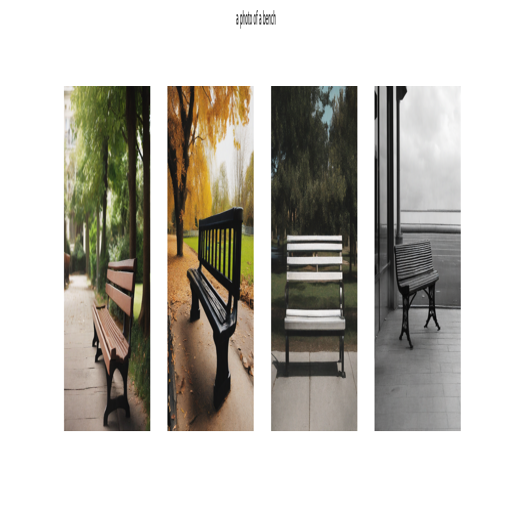

Lưới ảnh prompt /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100/00001/grid.png:


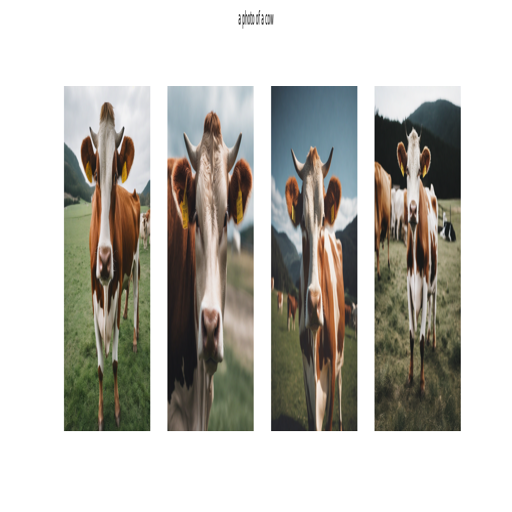

Lưới ảnh prompt /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100/00002/grid.png:


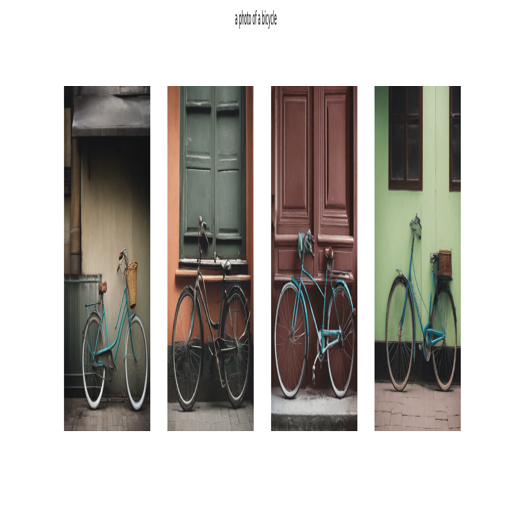

Lưới ảnh prompt /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100/00003/grid.png:


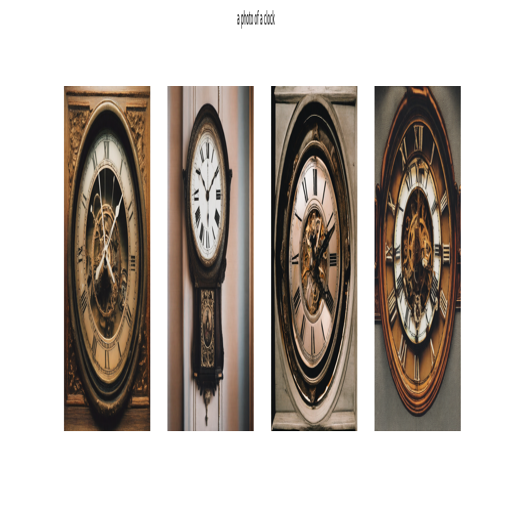

Lưới ảnh prompt /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100/00004/grid.png:


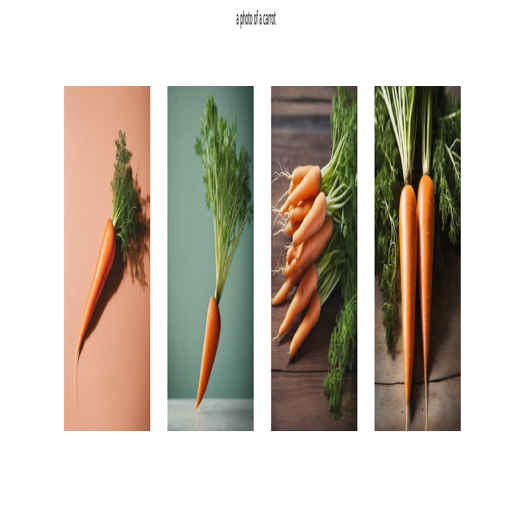

Lưới ảnh prompt /content/RS-LiDAR/Target_samples/RSLiDAR_SDXL_DPM8_Step8_n50_sig1.0_M4_DDPM100_s8.0_lmbda5000_seed100_A100/00005/grid.png:


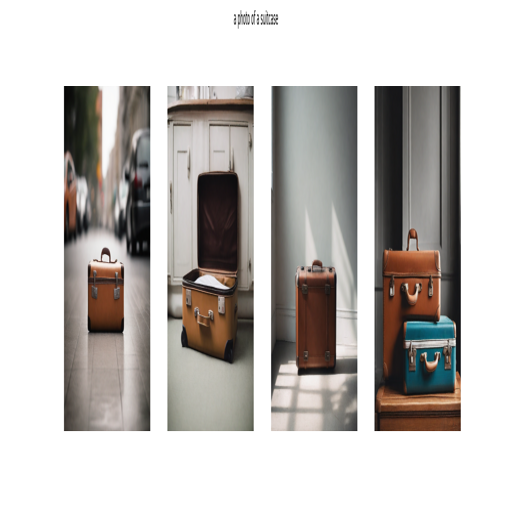

In [ ]:
import glob
from PIL import Image
from IPython.display import display

grid_images = sorted(glob.glob(f"{target_dir}/[0-9]*/*grid.png"))[:6]
if not grid_images:
    sample_images = sorted(glob.glob(f"{target_dir}/[0-9]*/samples/*.png"))[:6]
    for p in sample_images:
        print(f"Ảnh: {p}")
        display(Image.open(p).resize((384, 384)))
else:
    for p in grid_images:
        print(f"Lưới ảnh prompt {p}:")
        display(Image.open(p).resize((512, 512)))

## 10. (Tùy Chọn) Tự Động Ngắt Kết Nối Máy Ảo Để Tiết Kiệm Compute Units
Nếu bạn chạy qua đêm và muốn Colab tự động ngắt kết nối ngay khi xong toàn bộ (để dừng tính Compute Units), hãy bỏ dấu `#` ở 2 dòng dưới đây và chạy cell này.

In [ ]:
# from google.colab import runtime
# runtime.unassign()
print("🎉 Hoàn tất toàn bộ quy trình tái lập Bảng 2!")

🎉 Hoàn tất toàn bộ quy trình tái lập Bảng 2!
